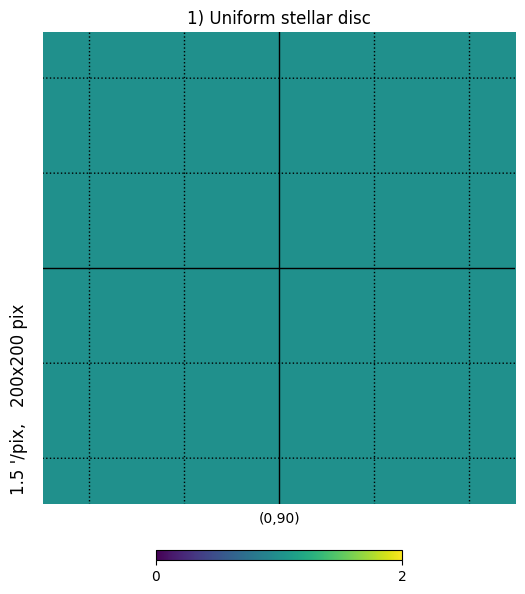

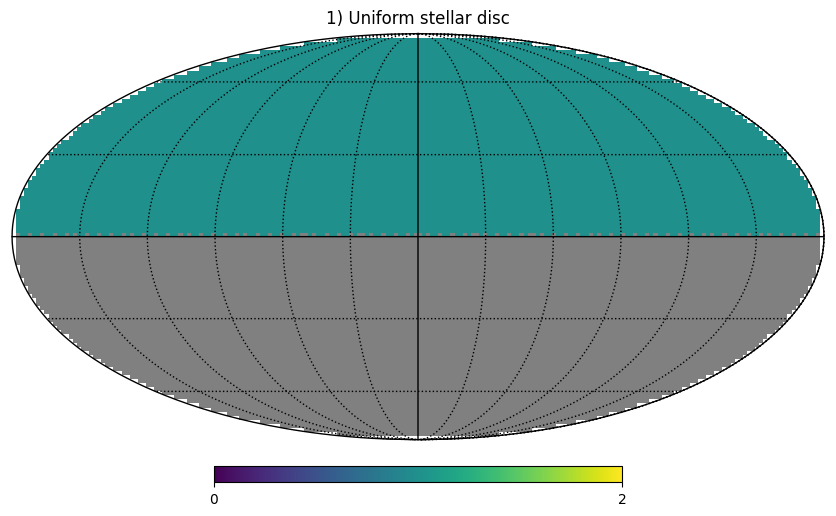

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# inline plotting
%matplotlib inline

# 1) MAKE A MAP OF A STAR
# -----------------------
NSIDE = 32
NPIX  = hp.nside2npix(NSIDE)
ipix  = np.arange(NPIX)

# get unit vectors for every pixel
x, y, z = hp.pix2vec(NSIDE, ipix)

# define the visible hemisphere (observer along +z)
visible = z > 0

# uniform‐brightness map
star_map = np.full(NPIX, hp.UNSEEN)
star_map[visible] = 1.0

# plot with a gnomonic projection centered on the sub‐observer point
hp.gnomview(
    star_map,
    rot=[0, 90],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()

hp.mollview(
    star_map,
    rot=[0, 0],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()


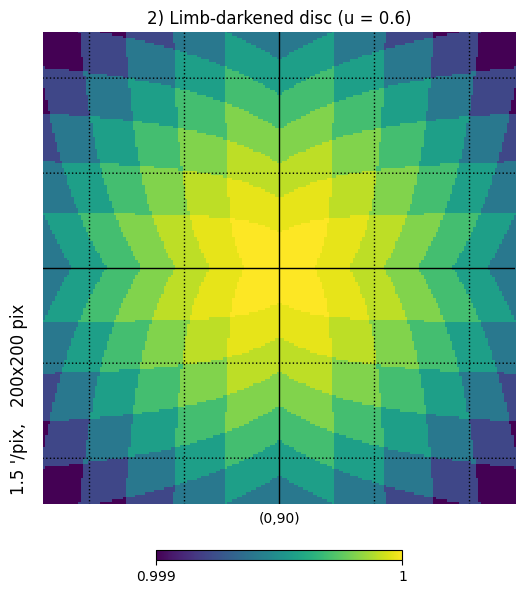

In [2]:
# 2) ADD LIMB DARKENING
# ---------------------
# Here we use a simple linear law:  I(μ) = 1 − u_ld (1 − μ),  with μ = cosθ = z
u_ld = 0.9

limb_map = np.full(NPIX, hp.UNSEEN)
# only on the visible pixels:
limb_map[visible] = 1.0 - u_ld * (1.0 - z[visible])

hp.gnomview(
    limb_map,
    rot=[0, 90],
    title="2) Limb‐darkened disc (u = 0.6)",
    xsize=200,
)
hp.graticule()


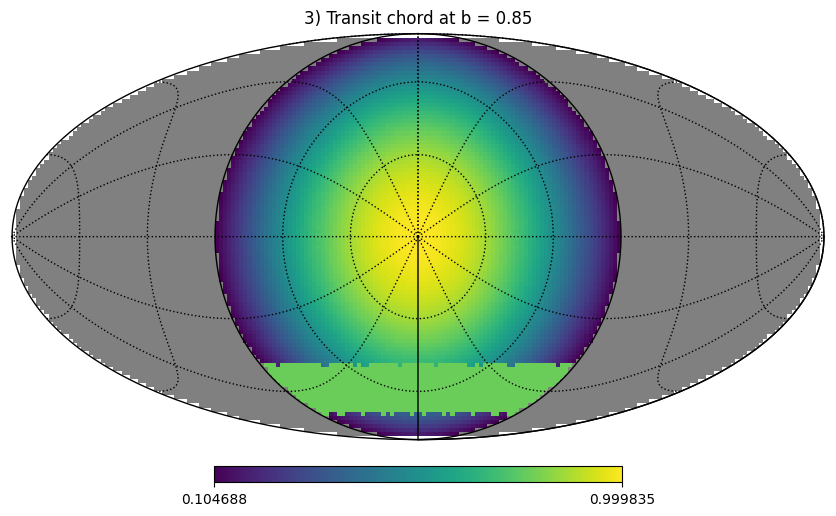

In [3]:
# 3) DEFINE A TRANSIT CHORD
# --------------------------
# For a planet with impact parameter b (in units of stellar radius), the chord
# runs at y = +b across the projected disc.  We’ll mask a narrow band around that.

b = 0.85              # impact parameter (0 = central, 1 = grazing)
chord_width = 0.1     # half‐width of the band

chord_mask = (np.abs(x - b) < chord_width) & visible

# visualize the chord alone
chord_map = np.full(NPIX, hp.UNSEEN)
chord_map[visible] = 1.0 - u_ld * (1.0 - z[visible])
chord_map[chord_mask] = 0.8

hp.mollview(
    chord_map,
    rot=[0, 90],
    title=f"3) Transit chord at b = {b}",
    xsize=200,
)
hp.graticule()


[-4.53990500e-01  8.91006524e-01  6.12323400e-17]


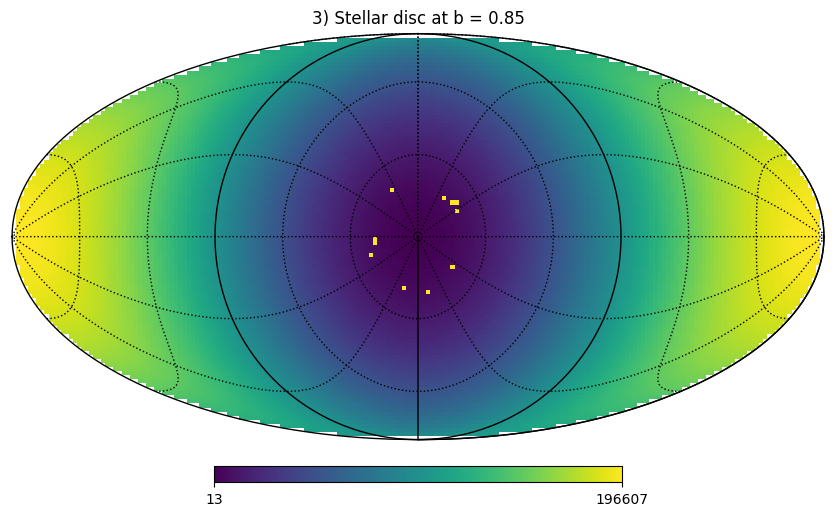

In [4]:
vec = hp.ang2vec(np.pi*0.5, np.pi*0.65)
print(vec)

ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))
m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(
    m,
    rot=[0, 90],
    title=f"3) Stellar disc at b = {b}",
    xsize=200,
)
hp.graticule()

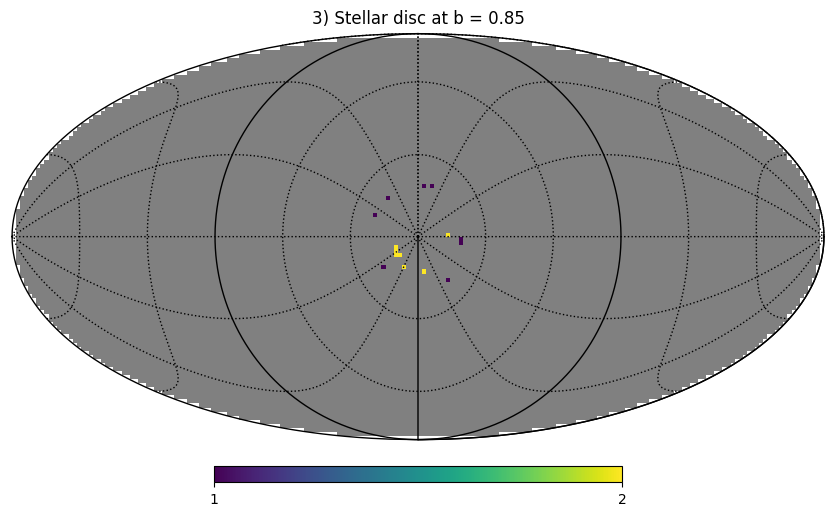

In [5]:
ipix_disc = hp.query_disc(nside=32, vec=np.array([0.5,1,0]), radius=np.radians(10))
ipix_disc2 = hp.query_disc(nside=32, vec=np.array([0.5,1,1]), radius=np.radians(10))
# visualize the disc alone
disc_map = np.full(NPIX, hp.UNSEEN)
disc_map[ipix_disc] = 1
disc_map[ipix_disc2] = 2
hp.mollview(
    disc_map,
    rot=[0, 90],
    title=f"3) Stellar disc at b = {b}",
    xsize=200,
)
hp.graticule()

In [6]:
# 4) TRANSIT MASK OVER TIME (horizontal chord)
# ---------------------------------------------
rp_rs   = 0.1      # planet radius in units of stellar radius
n_steps = 50

# chord spans y from −√(1−b²) to +√(1−b²):
y_min, y_max   = -np.sqrt(1 - b**2), np.sqrt(1 - b**2)
y_positions    = np.linspace(y_min, y_max, n_steps)

# baseline (unocculted) flux:
baseline_flux = limb_map[visible].sum()

flux = np.zeros(n_steps)
for i, yc in enumerate(y_positions):
    # planet disk centered at (x=b, y=yc) in the projected plane
    planet_occ = ((x - b)**2 + (y - yc)**2) < rp_rs**2

    # apply occultation
    m_blocked = limb_map.copy()
    m_blocked[planet_occ] = 0.0

    # sum only the visible pixels
    flux[i] = m_blocked[visible].sum() / baseline_flux


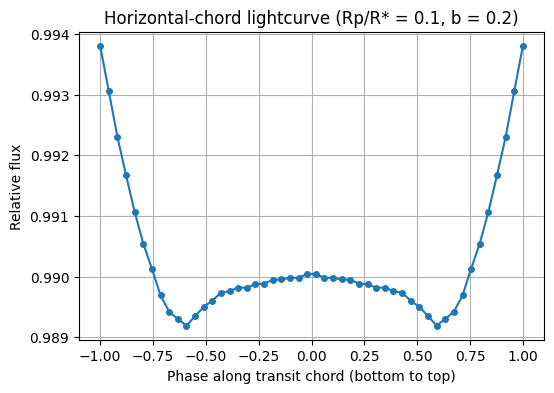

In [7]:
plt.figure(figsize=(6,4))
plt.plot(np.linspace(-1, 1, n_steps), flux, '-o', ms=4)
plt.xlabel("Phase along transit chord (bottom to top)")
plt.ylabel("Relative flux")
plt.title("Horizontal‐chord lightcurve (Rp/R* = 0.1, b = 0.2)")
plt.grid()
plt.show()


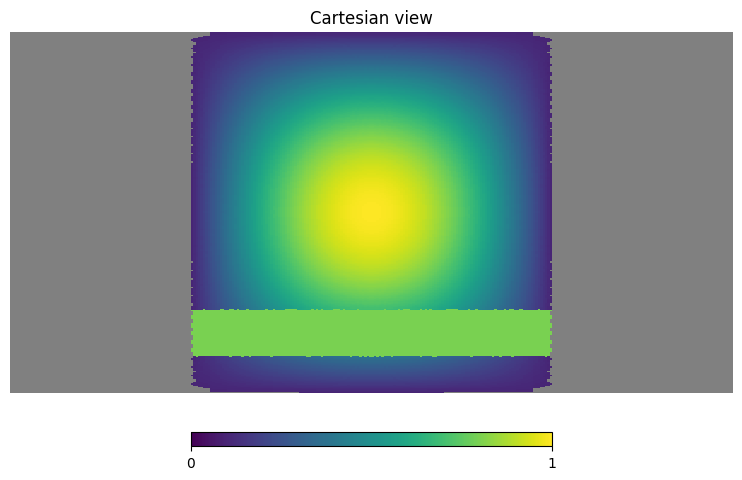

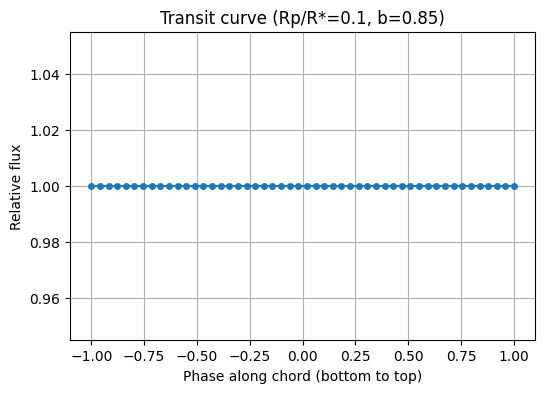

In [8]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# assume NSIDE, limb_map, b, rp_rs, n_steps defined as before

# 1) get a 2D Cartesian projection of your map
img = hp.cartview(
    chord_map,
    rot=[0, 90],
    xsize=300, ysize=300,
    return_projected_map=True,
    min=0, max=1,
)
ny, nx = img.shape

# 2) build the (x,y) grid in plane‐of‐sky units
xs = np.linspace(-1, 1, nx)
ys = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(xs, ys)

# 3) mask to within the stellar disk
disk_mask = (X**2 + Y**2) <= 1

# 4) compute baseline flux
baseline_flux = img[disk_mask].sum()

# 5) move planet *vertically* across the *horizontal* chord at x=b
flux = np.zeros(n_steps)
y_min, y_max = -np.sqrt(1 - b**2), np.sqrt(1 - b**2)
for i, yc in enumerate(np.linspace(y_min, y_max, n_steps)):
    planet_mask = ((X - b)**2 + (Y - yc)**2) <= rp_rs**2
    occulted = disk_mask & (~planet_mask)
    flux[i] = img[occulted].sum() / baseline_flux

# 6) plot
plt.figure(figsize=(6,4))
plt.plot(np.linspace(-1,1,n_steps), flux, '-o', ms=4)
plt.xlabel("Phase along chord (bottom to top)")
plt.ylabel("Relative flux")
plt.title(f"Transit curve (Rp/R*={rp_rs}, b={b})")
plt.grid()
plt.show()


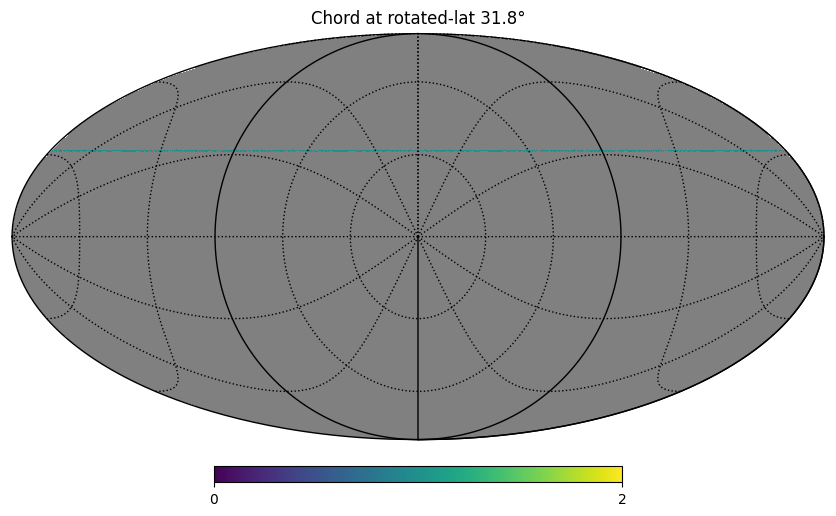

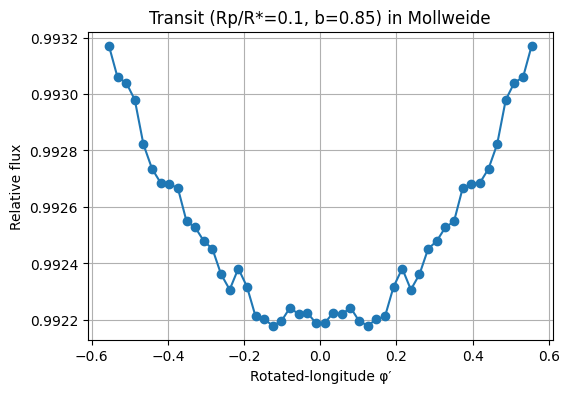

In [ ]:
import numpy as np
import healpy as hp
from healpy.rotator import Rotator
import matplotlib.pyplot as plt


# — assume NSIDE, limb_map, visible, b, rp_rs, n_steps defined —

# 1) Build a Rotator so that +z → “new” north pole (same as your hp.mollview rot=[0,90])
rot = Rotator(rot=[0, 90], deg=True)   # :contentReference[oaicite:0]{index=0}

# 2) Get original pixel vectors
ipix      = np.arange(hp.nside2npix(NSIDE))
xs, ys, zs = hp.pix2vec(NSIDE, ipix)   # shape (Npix,) each :contentReference[oaicite:1]{index=1}

# 3) Rotate them via rot(x,y,z)
x_r, y_r, z_r = rot(xs, ys, zs)         # returns three arrays of same shape :contentReference[oaicite:2]{index=2}

# 4) Compute spherical coords in rotated frame
theta_r = np.arccos(z_r)
phi_r   = np.arctan2(y_r, x_r)

# 5) Define chord as constant rotated‐latitude = LAT0
#    LAT0 chosen so chord sits at plane‐of‐sky impact parameter b:
lat0      = np.arcsin(np.sqrt(1 - b**2))
tol       = 0.005
chord_mask = np.abs((np.pi/2 - theta_r) - lat0) < tol

# visualize chord in Mollweide
chord_map = np.full_like(limb_map, hp.UNSEEN)
chord_map[chord_mask] = 1.0
hp.mollview(chord_map, rot=[0, 90], title=f"Chord at rotated‐lat {np.degrees(lat0):.1f}°")
hp.graticule()

# 6) Transit: march planet in rotated‐longitude φ′ at fixed lat0
baseline = limb_map[visible].sum()
flux     = np.zeros(n_steps)
phi_max  = np.arccos(b)                     # so chord runs −φ_max → +φ_max
phis     = np.linspace(-phi_max, phi_max, n_steps)

for i, φ0 in enumerate(phis):
    θp  = np.pi/2 - lat0
    sep = hp.rotator.angdist([θp, φ0], [theta_r, phi_r])
    occ = sep < np.arcsin(rp_rs)
    m2  = limb_map.copy()
    m2[occ] = 0.0
    flux[i] = m2[visible].sum() / baseline

# 7) Plot the lightcurve
plt.figure(figsize=(6,4))
plt.plot(phis, flux, '-o')
plt.xlabel("Rotated-longitude φ′")
plt.ylabel("Relative flux")
plt.title(f"Transit (Rp/R*={rp_rs}, b={b}) in Mollweide")
plt.grid()
plt.show()
